# MI benchmarking, PCA embeddings, and a combinatorial MI map of FP features

A follow-up to `mutual_information_sequence_traits.ipynb`. The shared building
blocks (the KSG estimator, the k-mer encoder, the PCA-embedding and MI helpers)
are reused verbatim. This notebook then does five things:

1. **Benchmark `ksg_mi`** against the closed-form MI of (possibly
   high-dimensional) Gaussians, and against `sklearn` where it applies.
2. **PCA of the k=2-mer sequence representation** across dimensions; save the
   10-PC embedding to `./processed_data/PCA_seq_ebd.txt`.
3. **PCA of the excitation and emission spectra** separately; save both 10-PC
   embeddings to `./processed_data/`.
4. **Combinatorial MI** across every pair of {sequence, excitation, emission,
   scalar traits}, null-corrected, shown as a heatmap.
5. **Sequence vs everything else** — one uniform bar plot of all MI estimates
   between the sequence and the remaining features.

## 0. Shared building blocks (reused from the original notebook)

In [1]:
import os
from itertools import product, combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import slogdet
from scipy.spatial import cKDTree
from scipy.special import digamma
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression

rng = np.random.default_rng(0)
plt.rcParams["figure.dpi"] = 110

DATA = "fpbase_output/fpbase_proteins.csv"
SPECTRA = "fpbase_output/fpbase_spectra_long.csv"
TRAITS = ["ex_max", "em_max", "ext_coeff", "qy", "brightness", "pka", "maturation"]
NATS_TO_BITS = 1.0 / np.log(2)
K_NN = 5
N_PERM = 200

df = pd.read_csv(DATA)
print("proteins table:", df.shape, "| rows with a sequence:", df["seq"].notna().sum())

proteins table: (1177, 34) | rows with a sequence: 1115


In [3]:
# --- KSG estimator (verbatim from the original notebook) ---
def ksg_mi(X, Y, k=5, noise=1e-10, seed=0):
    "KSG (Kraskov 2004) algorithm-1 estimate of I(X;Y) in nats. X:(N,dx), Y:(N,dy)/(N,)."
    rng = np.random.default_rng(seed)
    X = np.asarray(X, float); Y = np.asarray(Y, float)
    if X.ndim == 1: X = X[:, None]
    if Y.ndim == 1: Y = Y[:, None]
    N = X.shape[0]
    X = (X - X.mean(0)) / (X.std(0) + 1e-12) + noise * rng.standard_normal(X.shape)
    Y = (Y - Y.mean(0)) / (Y.std(0) + 1e-12) + noise * rng.standard_normal(Y.shape)
    XY = np.hstack([X, Y])
    dist, _ = cKDTree(XY).query(XY, k=k + 1, p=np.inf)
    eps = dist[:, k]
    nx1 = cKDTree(X).query_ball_point(X, eps - 1e-12, p=np.inf, return_length=True)
    ny1 = cKDTree(Y).query_ball_point(Y, eps - 1e-12, p=np.inf, return_length=True)
    mi = digamma(k) + digamma(N) - np.mean(digamma(nx1) + digamma(ny1))
    return max(mi, 0.0)


# --- k-mer encoder (verbatim) ---
AA = "ACDEFGHIKLMNPQRSTVWY"
K = 2
VOCAB = ["".join(p) for p in product(AA, repeat=K)]
VIDX = {km: i for i, km in enumerate(VOCAB)}

def kmer_freq(seq, k=K):
    """Normalized (L1) k-mer frequency vector for one sequence.

    Non-canonical residues are treated as breakpoints so k-mers are only
    counted within contiguous runs of standard amino acids.
    """
    v = np.zeros(len(VOCAB))
    run = []

    def count_run(chars):
        if len(chars) < k:
            return
        s = "".join(chars)
        for i in range(len(s) - k + 1):
            v[VIDX[s[i:i+k]]] += 1.0

    for c in str(seq).upper():
        if c in AA:
            run.append(c)
        else:
            count_run(run)
            run = []

    count_run(run)
    tot = v.sum()
    return v / tot if tot > 0 else v


# --- PCA embedding + spectrum resampler + MI-with-null helpers (reused) ---
def pca_embed(matrix, index, n_comp=10):
    "Standardize -> PCA -> DataFrame(index, PC1..PCn). Returns (embedding_df, fitted_full_pca)."
    Mz = StandardScaler().fit_transform(matrix)
    Z = PCA(n_components=n_comp, random_state=0).fit_transform(Mz)
    cols = [f"PC{i+1}" for i in range(n_comp)]
    emb = pd.DataFrame(Z, index=pd.Index(index, name="slug"), columns=cols)
    return emb, PCA(random_state=0).fit(Mz)

def resample_by_slug(sub, grid):
    "slug -> intensity resampled onto grid, averaging over any multiple states."
    out = {}
    for slug, g in sub.groupby("slug"):
        gg = g.groupby("wavelength")["intensity"].mean()
        out[slug] = np.interp(grid, gg.index.to_numpy(), gg.to_numpy(), left=0.0, right=0.0)
    return out

def mi_with_null(X, Y, k=K_NN, n_perm=N_PERM):
    "I(X;Y) in bits plus a paired-shuffle null. X,Y are aligned arrays."
    mi = ksg_mi(X, Y, k=k)
    null = np.array([ksg_mi(X, Y[rng.permutation(len(Y))], k=k, seed=p + 1) for p in range(n_perm)])
    return dict(mi_bits=mi * NATS_TO_BITS,
                net_bits=(mi - null.mean()) * NATS_TO_BITS,
                null_mean_bits=null.mean() * NATS_TO_BITS,
                null_std_bits=null.std() * NATS_TO_BITS,
                z=(mi - null.mean()) / (null.std() + 1e-12),
                p=(np.sum(null >= mi) + 1) / (n_perm + 1))

def stars(p):
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else "ns"

## 1. Benchmark `ksg_mi` against Gaussian theory and `sklearn`

For jointly Gaussian variables the MI is known in closed form. We use a clean
construction: $X \in \mathbb{R}^d$ standard normal and $Y_i = \rho X_i +
\sqrt{1-\rho^2}\,\varepsilon_i$ with independent $\varepsilon$. Each coordinate
pair is correlated by $\rho$ and the dimensions are mutually independent, so

$$I(X;Y) = -\tfrac{d}{2}\ln(1-\rho^2)\ \text{nats}.$$

Because the dimensions are independent, `sklearn.mutual_info_regression` — which
only accepts a 1-D target — can still produce a *joint* estimate as the sum of
its per-coordinate 1-D MIs. That is the "sklearn (per-dim sum)" reference; it is
only valid for this independent-coordinate construction.

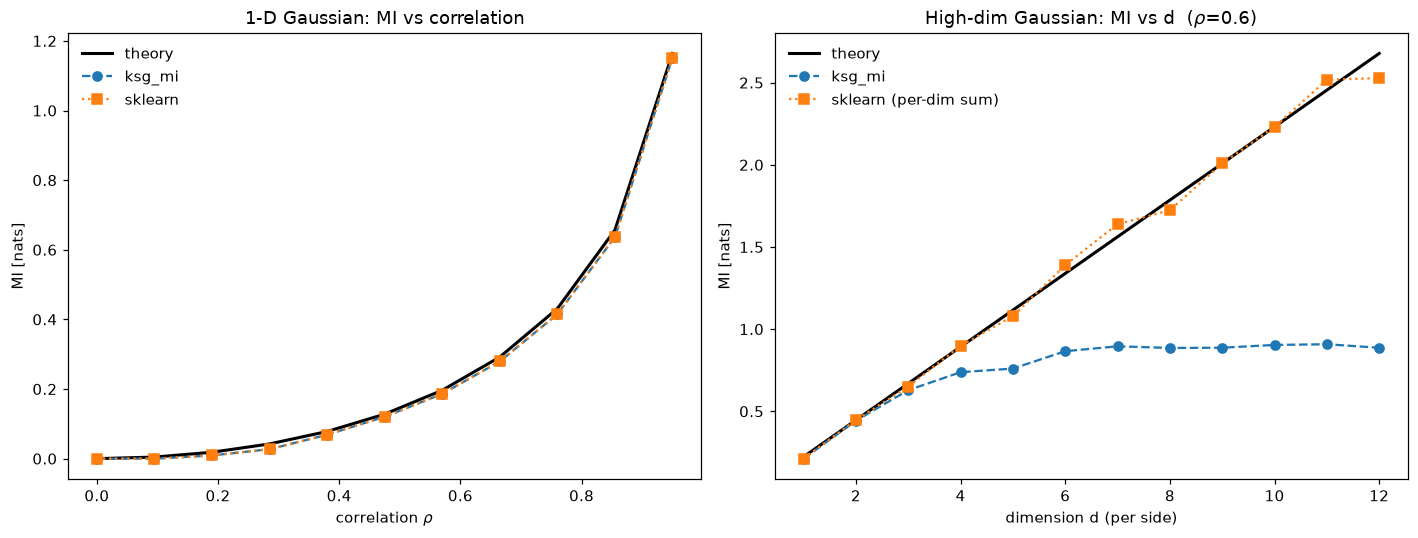

In [4]:
def gaussian_pairs(d, rho, n, seed):
    rg = np.random.default_rng(seed)
    X = rg.standard_normal((n, d))
    E = rg.standard_normal((n, d))
    Y = rho * X + np.sqrt(1 - rho**2) * E
    return X, Y

def theory_nats(d, rho):
    return -0.5 * d * np.log(1 - rho**2)

def sklearn_sum_nats(X, Y, k=K_NN):
    "Joint MI as sum of per-coordinate 1-D sklearn estimates (valid only for independent dims)."
    return float(sum(mutual_info_regression(X[:, [i]], Y[:, i], n_neighbors=k, random_state=0)[0]
                     for i in range(X.shape[1])))

N_BM = 2000
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5))

# (A) 1-D, sweep correlation
rhos = np.linspace(0.0, 0.95, 11)
ks_a = [ksg_mi(*gaussian_pairs(1, r, N_BM, 0), k=K_NN) for r in rhos]
sk_a = [sklearn_sum_nats(*gaussian_pairs(1, r, N_BM, 0)) for r in rhos]
th_a = [theory_nats(1, r) for r in rhos]
axA.plot(rhos, th_a, "k-", lw=2, label="theory")
axA.plot(rhos, ks_a, "o--", color="tab:blue", label="ksg_mi")
axA.plot(rhos, sk_a, "s:", color="tab:orange", label="sklearn")
axA.set_xlabel(r"correlation $\rho$"); axA.set_ylabel("MI [nats]")
axA.set_title("1-D Gaussian: MI vs correlation"); axA.legend(frameon=False)

# (B) high-dimensional, sweep d at fixed rho
RHO = 0.6
ds = np.arange(1, 13)
ks_b = [ksg_mi(*gaussian_pairs(d, RHO, N_BM, 0), k=K_NN) for d in ds]
sk_b = [sklearn_sum_nats(*gaussian_pairs(d, RHO, N_BM, 0)) for d in ds]
th_b = [theory_nats(d, RHO) for d in ds]
axB.plot(ds, th_b, "k-", lw=2, label="theory")
axB.plot(ds, ks_b, "o--", color="tab:blue", label="ksg_mi")
axB.plot(ds, sk_b, "s:", color="tab:orange", label="sklearn (per-dim sum)")
axB.set_xlabel("dimension d (per side)"); axB.set_ylabel("MI [nats]")
axB.set_title(rf"High-dim Gaussian: MI vs d  ($\rho$={RHO})"); axB.legend(frameon=False)
plt.tight_layout(); plt.show()

In [5]:
# numeric benchmark table (high-dim cases)
print(f"{'d':>3} {'rho':>5} {'theory':>8} {'ksg_mi':>8} {'sklearn':>8} {'ksg_err%':>9}")
for d, rho in [(1, 0.6), (3, 0.6), (5, 0.6), (10, 0.6), (15, 0.6), (5, 0.3), (5, 0.85)]:
    X, Y = gaussian_pairs(d, rho, N_BM, 0)
    th = theory_nats(d, rho)
    ks = ksg_mi(X, Y, k=K_NN)
    sk = sklearn_sum_nats(X, Y)
    print(f"{d:>3} {rho:>5} {th:>8.3f} {ks:>8.3f} {sk:>8.3f} {100*(ks-th)/th:>8.1f}%")

  d   rho   theory   ksg_mi  sklearn  ksg_err%
  1   0.6    0.223    0.212    0.212     -5.1%
  3   0.6    0.669    0.629    0.650     -6.1%
  5   0.6    1.116    0.760    1.079    -31.9%
 10   0.6    2.231    0.904    2.230    -59.5%
 15   0.6    3.347    0.873    3.123    -73.9%
  5   0.3    0.236    0.156    0.218    -34.0%
  5  0.85    3.205    2.138    3.210    -33.3%


## 2. PCA of the k=2-mer sequence representation

We build the k=2-mer frequency matrix at the **protein (slug) level** (one
sequence per protein), standardize, and evaluate how cumulative explained
variance grows with the number of PCs. The 10-PC embedding is saved to
`./processed_data/PCA_seq_ebd.txt` (tab-separated, slug-indexed).

In [6]:
os.makedirs("processed_data", exist_ok=True)

seq_by_slug = df.dropna(subset=["seq"]).drop_duplicates("slug").set_index("slug")["seq"]
F_seq = np.vstack([kmer_freq(s) for s in seq_by_slug])
print(f"sequence k-mer matrix: {F_seq.shape}  ({len(seq_by_slug)} proteins x {len(VOCAB)} {K}-mers)")

seq_emb, seq_pca_full = pca_embed(F_seq, seq_by_slug.index, n_comp=10)
seq_cum = np.cumsum(seq_pca_full.explained_variance_ratio_)

# evaluate across dimensions
for q in [2, 5, 10, 20, 50]:
    print(f"  {q:>2} PCs -> {seq_cum[q-1]:.1%} cumulative variance")

out_path = "processed_data/PCA_seq_ebd.txt"
seq_emb.to_csv(out_path, sep="\t")
print("saved 10-PC sequence embedding ->", out_path, seq_emb.shape)

sequence k-mer matrix: (990, 400)  (990 proteins x 400 2-mers)
   2 PCs -> 22.0% cumulative variance
   5 PCs -> 34.8% cumulative variance
  10 PCs -> 45.2% cumulative variance
  20 PCs -> 58.3% cumulative variance
  50 PCs -> 77.6% cumulative variance
saved 10-PC sequence embedding -> processed_data/PCA_seq_ebd.txt (990, 10)


## 3. PCA of the excitation and emission spectra (separately)

Each protein's excitation and emission curves are resampled onto a common
350-750 nm grid, then PCA'd **separately**. We evaluate the variance curves and
save each 10-PC embedding to `./processed_data/`.

In [7]:
spec = pd.read_csv(SPECTRA)
GRID = np.arange(350, 751, 2)

ex_map = resample_by_slug(spec[spec.spectrum_type == "excitation"], GRID)
em_map = resample_by_slug(spec[spec.spectrum_type == "emission"], GRID)

def build_spectrum_embedding(intensity_map, name, fname):
    keys = sorted(intensity_map)
    M = np.vstack([intensity_map[s] for s in keys])
    emb, pca_full = pca_embed(M, keys, n_comp=10)
    cum = np.cumsum(pca_full.explained_variance_ratio_)
    print(f"{name}: matrix {M.shape}  | 10-PC variance = {cum[9]:.1%}")
    path = f"processed_data/{fname}"
    emb.to_csv(path, sep="\t")
    print("  saved ->", path, emb.shape)
    return emb, cum

ex_emb, ex_cum = build_spectrum_embedding(ex_map, "excitation", "PCA_excitation_ebd.txt")
em_emb, em_cum = build_spectrum_embedding(em_map, "emission",   "PCA_emission_ebd.txt")

excitation: matrix (452, 201)  | 10-PC variance = 95.5%
  saved -> processed_data/PCA_excitation_ebd.txt (452, 10)
emission: matrix (451, 201)  | 10-PC variance = 95.8%
  saved -> processed_data/PCA_emission_ebd.txt (451, 10)


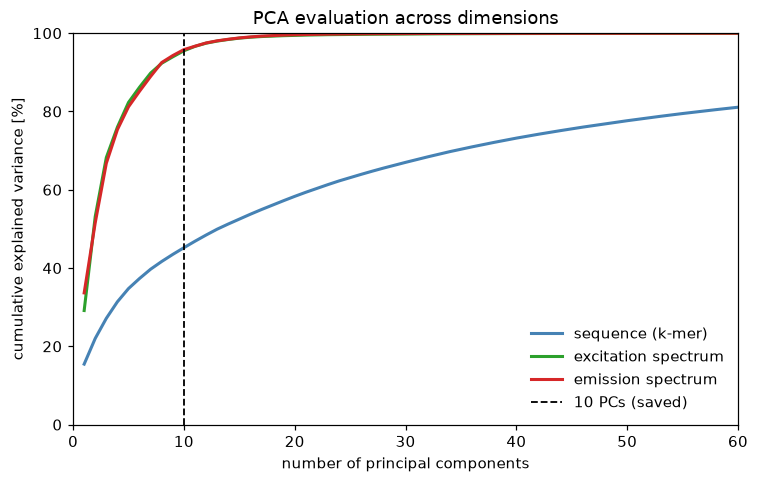

In [8]:
# evaluate PCA across dimensions for all three representations on one figure
fig, ax = plt.subplots(figsize=(7, 4.5))
for cum, lab, c in [(seq_cum, "sequence (k-mer)", "steelblue"),
                    (ex_cum, "excitation spectrum", "tab:green"),
                    (em_cum, "emission spectrum", "tab:red")]:
    ax.plot(np.arange(1, len(cum) + 1), cum * 100, lw=2, color=c, label=lab)
ax.axvline(10, color="black", ls="--", lw=1.2, label="10 PCs (saved)")
ax.set_xlim(0, 60); ax.set_ylim(0, 100)
ax.set_xlabel("number of principal components")
ax.set_ylabel("cumulative explained variance [%]")
ax.set_title("PCA evaluation across dimensions")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

## 4. Combinatorial MI across all feature pairs

We assemble every feature into a common slug-indexed table:

- **sequence** (10-PC k-mer embedding)
- **excitation**, **emission** (10-PC spectral embeddings)
- the seven **scalar traits**

For every unordered pair we estimate the KSG MI on the proteins shared by both,
subtract the shuffled-pairing null (so the value is "blanked by the null model"),
and report the **net MI in bits**. The result is a symmetric heatmap.

In [9]:
# feature registry: name -> slug-indexed DataFrame (embeddings) or 1-col frame (scalars)
traits_by_slug = df.groupby("slug")[TRAITS].mean()
features = {"sequence": seq_emb, "excitation": ex_emb, "emission": em_emb}
for t in TRAITS:
    features[t] = traits_by_slug[[t]]
NAMES = list(features)

N_PERM_MAT = 100
MIN_N = 30

def aligned(a, b):
    A, B = features[a].dropna(), features[b].dropna()
    idx = A.index.intersection(B.index)
    return idx, A.loc[idx].to_numpy(), B.loc[idx].to_numpy()

pair_stats = {}            # frozenset({a,b}) -> stats dict (+ n)
for a, b in combinations(NAMES, 2):
    idx, X, Y = aligned(a, b)
    if len(idx) < MIN_N:
        pair_stats[frozenset((a, b))] = dict(net_bits=np.nan, z=np.nan, p=np.nan, n=len(idx))
        continue
    s = mi_with_null(X, Y, k=K_NN, n_perm=N_PERM_MAT)
    s["n"] = len(idx)
    pair_stats[frozenset((a, b))] = s

# symmetric net-MI matrix (diagonal = NaN)
M = pd.DataFrame(np.nan, index=NAMES, columns=NAMES)
for a, b in combinations(NAMES, 2):
    v = pair_stats[frozenset((a, b))]["net_bits"]
    M.loc[a, b] = M.loc[b, a] = v
M.round(3)

,sequence,excitation,emission,ex_max,em_max,ext_coeff,qy,brightness,pka,maturation
sequence,NaN,1.416,1.793,1.291,1.390,0.460,0.655,0.540,0.368,0.181
excitation,1.416,NaN,2.888,1.797,1.605,0.594,0.599,0.602,0.333,0.197
emission,1.793,2.888,NaN,1.954,2.087,0.525,0.728,0.596,0.321,0.150
ex_max,1.291,1.797,1.954,NaN,2.663,0.505,0.552,0.481,0.274,0.344
em_max,1.390,1.605,2.087,2.663,NaN,0.327,0.570,0.406,0.254,0.278
ext_coeff,0.460,0.594,0.525,0.505,0.327,NaN,0.119,0.880,0.195,-0.018
qy,0.655,0.599,0.728,0.552,0.570,0.119,NaN,1.078,0.199,0.072
brightness,0.540,0.602,0.596,0.481,0.406,0.880,1.078,NaN,0.142,0.014
pka,0.368,0.333,0.321,0.274,0.254,0.195,0.199,0.142,NaN,0.089
maturation,0.181,0.197,0.150,0.344,0.278,-0.018,0.072,0.014,0.089,NaN


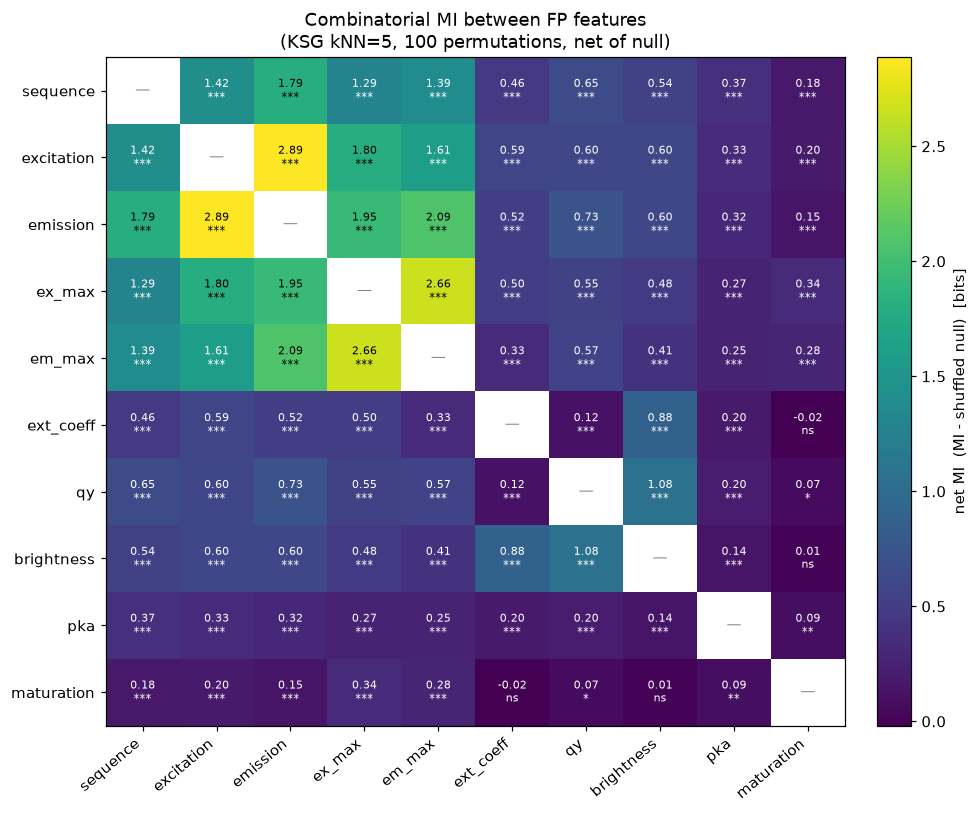

In [10]:
fig, ax = plt.subplots(figsize=(9, 7.5))
data = M.to_numpy(dtype=float)
im = ax.imshow(np.ma.masked_invalid(data), cmap="viridis", aspect="auto")
ax.set_xticks(range(len(NAMES))); ax.set_xticklabels(NAMES, rotation=40, ha="right")
ax.set_yticks(range(len(NAMES))); ax.set_yticklabels(NAMES)
for i, a in enumerate(NAMES):
    for j, b in enumerate(NAMES):
        if i == j:
            ax.text(j, i, "—", ha="center", va="center", color="gray")
        elif np.isfinite(data[i, j]):
            st = pair_stats[frozenset((a, b))]
            ax.text(j, i, f"{data[i, j]:.2f}\n{stars(st['p'])}",
                    ha="center", va="center", fontsize=7,
                    color="white" if data[i, j] < np.nanmax(data) * 0.6 else "black")
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.set_label("net MI  (MI - shuffled null)  [bits]")
ax.set_title(f"Combinatorial MI between FP features\n(KSG kNN={K_NN}, {N_PERM_MAT} permutations, net of null)")
plt.tight_layout(); plt.show()

## 5. Sequence vs everything else — one uniform bar plot

Pulling the **sequence** row out of the combinatorial map gives every MI estimate
between the amino-acid sequence and the other features (spectra + scalar traits)
on a single comparable axis. Bars are net MI in bits; annotations give the
permutation significance, the z-score, and the sample size.

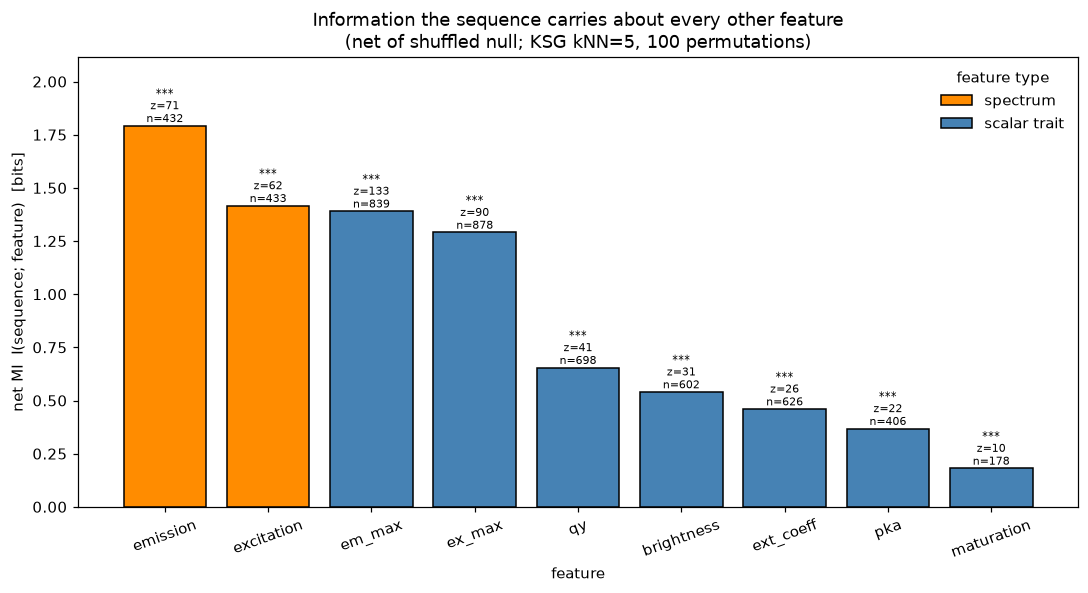

,feature,net_bits,mi_bits,z,p,n
0,emission,1.793,1.810,71.421,0.01,432
1,excitation,1.416,1.431,61.769,0.01,433
2,em_max,1.390,1.397,132.958,0.01,839
3,ex_max,1.291,1.299,89.965,0.01,878
4,qy,0.655,0.667,40.643,0.01,698
5,brightness,0.540,0.553,30.782,0.01,602
6,ext_coeff,0.460,0.470,25.771,0.01,626
7,pka,0.368,0.380,22.174,0.01,406
8,maturation,0.181,0.192,9.721,0.01,178


In [11]:
others = [n for n in NAMES if n != "sequence"]
seq_rows = []
for o in others:
    s = pair_stats[frozenset(("sequence", o))]
    seq_rows.append(dict(feature=o, **s))
seq_vs = pd.DataFrame(seq_rows).sort_values("net_bits", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5.5))
kind = ["spectrum" if f in ("excitation", "emission") else "scalar trait" for f in seq_vs["feature"]]
palette = {"spectrum": "darkorange", "scalar trait": "steelblue"}
bar_colors = [palette[k] for k in kind]

bars = ax.bar(seq_vs["feature"], seq_vs["net_bits"], color=bar_colors, edgecolor="black")
for b, (_, r) in zip(bars, seq_vs.iterrows()):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
            f"{stars(r.p)}\nz={r.z:.0f}\nn={int(r.n)}", ha="center", va="bottom", fontsize=7)

handles = [plt.Rectangle((0, 0), 1, 1, color=c, ec="black") for c in palette.values()]
ax.legend(handles, palette.keys(), frameon=False, title="feature type")
ax.set_ylabel("net MI  I(sequence; feature)  [bits]")
ax.set_xlabel("feature")
ax.set_title(f"Information the sequence carries about every other feature\n"
             f"(net of shuffled null; KSG kNN={K_NN}, {N_PERM_MAT} permutations)")
ax.margins(y=0.18)
plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

seq_vs[["feature", "net_bits", "mi_bits", "z", "p", "n"]].round(3)

### Notes

- **Benchmark (1):** `ksg_mi` tracks the Gaussian theory closely in low dimension
  and matches `sklearn` on the 1-D case; in high dimension it (like all kNN MI
  estimators) increasingly *under*-estimates the true MI — see the growing gap in
  panel B and the `ksg_err%` column. This is the curse-of-dimensionality bias and
  is exactly why the real-data sections keep representations compact (10 PCs) and
  always report MI relative to a permutation null.
- **Embeddings (2-3):** saved under `./processed_data/` as tab-separated,
  slug-indexed text — reload with `pd.read_csv(path, sep="\t", index_col=0)`.
- **MI map & bar plot (4-5):** values are net of the shuffled-pairing null, so
  they are comparable across pairs with different sample sizes; absolute
  magnitudes are still lower bounds (10-PC truncation) and biased downward in the
  higher-dimensional pairs, so read them alongside the z-scores.